# Testing Fujifilm prescale calibration

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = Image.open('prescale-test.png').convert('RGB')
data = np.array(img)

## 1.0 Colour channels

Extract the colour channels here (R,G,B). The staining is magenta, so green should be very low in the staining (red and blue dominate). Green also has the widest dynamic range, so pick it for further analysis.

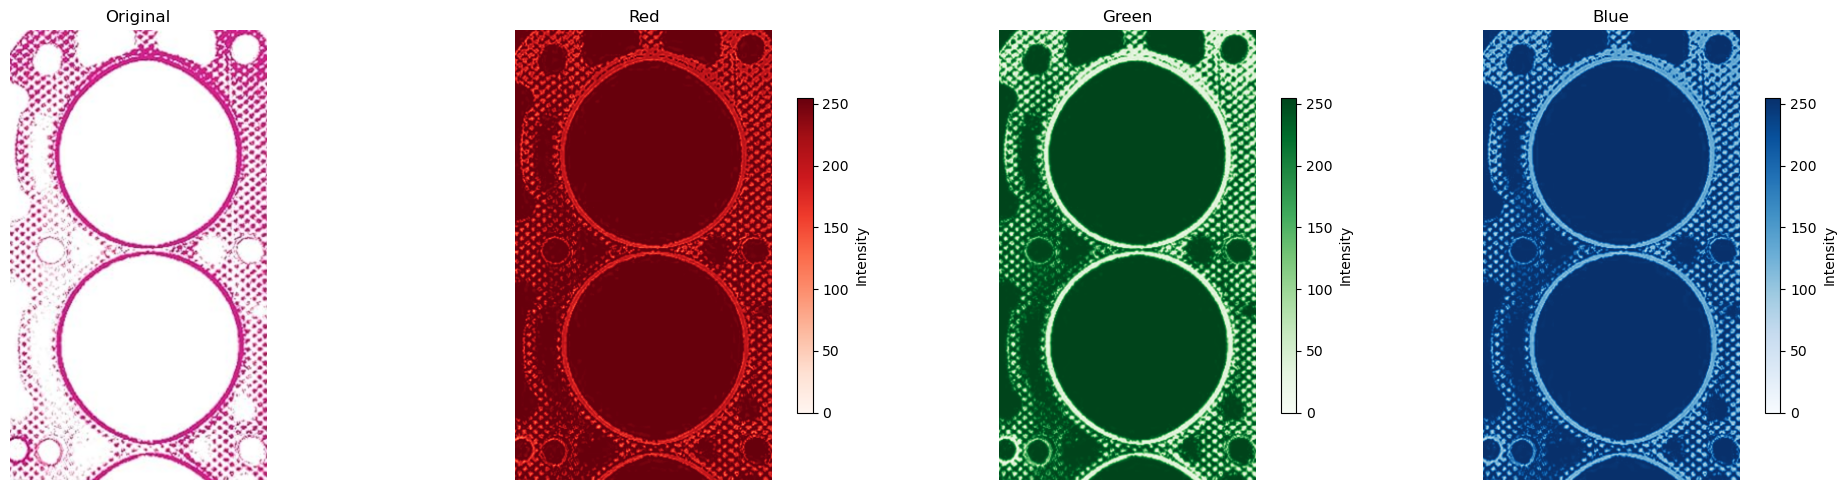

In [3]:
red = data[:, :, 0].astype(float)
green = data[:, :, 1].astype(float)
blue = data[:, :, 2].astype(float)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

im0 = axes[0].imshow(img)
axes[0].set_title('Original')

im1 = axes[1].imshow(red, cmap='Reds', vmin=0, vmax=255)
fig.colorbar(im1, ax=axes[1], shrink=0.7, label='Intensity')
axes[1].set_title('Red')

im2 = axes[2].imshow(green, cmap='Greens', vmin=0, vmax=255)
fig.colorbar(im2, ax=axes[2], shrink=0.7, label='Intensity')
axes[2].set_title('Green')

im3 = axes[3].imshow(blue, cmap='Blues', vmin=0, vmax=255)
fig.colorbar(im3, ax=axes[3], shrink=0.7, label='Intensity')
axes[3].set_title('Blue')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2.0 Optical density

OD = $-log_{10} (G / G_{0})$

Where:
- $G$  = green channel pixel value
- $G_{0}$ = green channel value of unstained film (white reference)

White reference G0: 255.0


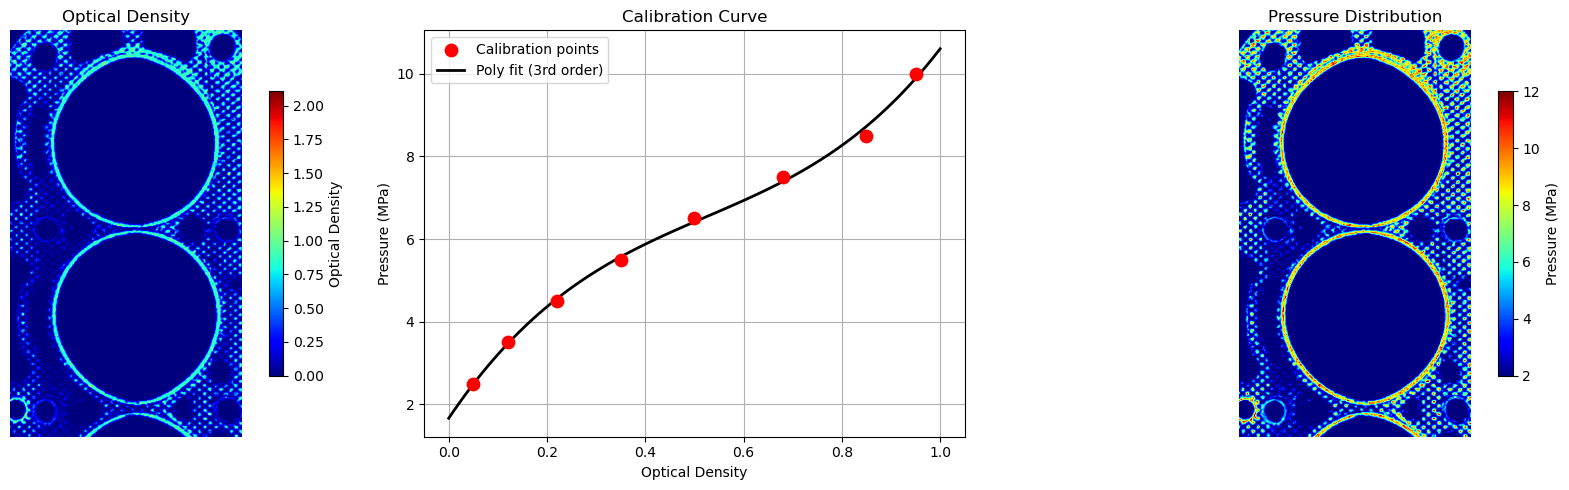

In [4]:
g0 = green[600:700, 200:300].mean()
print(f'White reference G0: {g0}')

green = np.clip(green, 1, None)
od = -np.log10(green / g0)

# calibration data
od_cal = np.array([0.05, 0.12, 0.22, 0.35, 0.50, 0.68, 0.85, 0.95])
p_cal = np.array([2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 10.0])

coeffs = np.polyfit(od_cal, p_cal, 3)
poly = np.poly1d(coeffs)

# apply calibration
pressure_map = poly(od)
pressure_map = np.clip(pressure_map, 0, 12)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# optical density
im0 = axes[0].imshow(od, cmap='jet')
fig.colorbar(im0, ax=axes[0], shrink=0.7, label='Optical Density')
axes[0].set_title('Optical Density')
axes[0].axis('off')

# calibration curve
od_fit = np.linspace(0, 1.0, 100)
axes[1].scatter(od_cal, p_cal, color='red', s=80, zorder=5, label='Calibration points')
axes[1].plot(od_fit, poly(od_fit), 'k-', linewidth=2, label='Poly fit (3rd order)')
axes[1].set_xlabel('Optical Density')
axes[1].set_ylabel('Pressure (MPa)')
axes[1].set_title('Calibration Curve')
axes[1].legend()
axes[1].grid(True)

# pressure map
im2 = axes[2].imshow(pressure_map, cmap='jet', vmin=2, vmax=12)
fig.colorbar(im2, ax=axes[2], shrink=0.7, label='Pressure (MPa)')
axes[2].set_title('Pressure Distribution')
axes[2].axis('off')

plt.tight_layout()
plt.show()